# Semana 4 – Regularización

Comparar base vs regularizado y evidenciar generalización.

## Evidencia esperada
- Base vs regularizado
- Train vs valid/test
- Conclusiones

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configuración inicial
np.random.seed(7)
tf.random.set_seed(7)
random.seed(7)
# Carga y Preparación de datos (Diabetes convertido a Clasificación)
data = load_diabetes()
# Convertimos a binario: 1 si está por encima de la mediana, 0 si no.
X, y = data.data, (data.target > np.median(data.target)).astype(int)
# Partición de datos con random_state fijo para consistencia
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

# Escalamiento de características
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# CALLBACK PARA PARADA TEMPRANA
# Detiene el entrenamiento cuando el val_loss deja de bajar y restaura los mejores pesos.
parada_temprana = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

## Modelo base

Entrenar sin regularización.

In [65]:
# Definición del modelo base (sin regularización)
def modelo_base():
    model = keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Entrenamiento sin regularización
m_base = modelo_base()
h_base = m_base.fit(X_train_s, y_train, validation_split=0.2, epochs=80, batch_size=32, verbose=0)

# Evaluación
res_base = m_base.evaluate(X_test_s, y_test, verbose=0)
print(f"Base test: {res_base} | best val_loss: {min(h_base.history['val_loss'])}")



Base test: [0.48160991072654724, 0.8089887499809265] | best val_loss: 0.49180006980895996


## Modelo regularizado

 Aplicar regularización y entrenar.

In [66]:
#  Definición del modelo con regularización (Dropout)
def modelo_dropout():
    model = keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),  # Regularización: Dropout al 20% para notar el efecto
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Entrenamiento con regularización
m_reg = modelo_dropout()
h_reg = m_reg.fit(X_train_s, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=0)

# Evaluación
res_reg = m_reg.evaluate(X_test_s, y_test, verbose=0)
print(f"Regularizado (Dropout)  test: {res_reg} | best val_loss: {min(h_reg.history['val_loss'])}")






Regularizado (Dropout)  test: [0.4595915675163269, 0.8089887499809265] | best val_loss: 0.4789975583553314


## Comparación

Evidencia de overfitting y efecto.

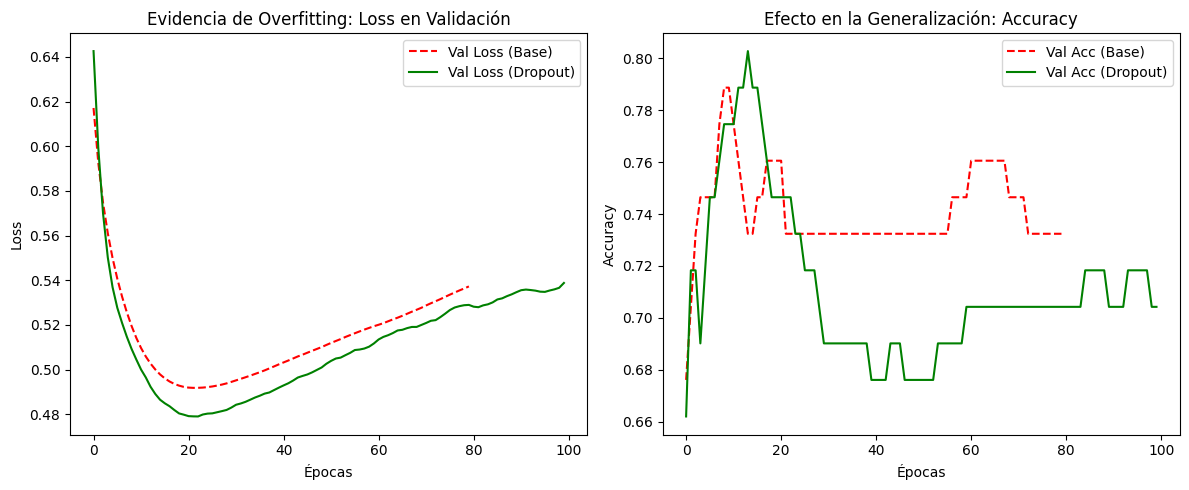

In [67]:
# Visualización de la Generalización
plt.figure(figsize=(12, 5))

# Gráfico de Loss (Evidencia de Overfitting vs Estabilidad)
plt.subplot(1, 2, 1)
plt.plot(h_base.history['val_loss'], label='Val Loss (Base)', color='red', linestyle='--')
plt.plot(h_reg.history['val_loss'], label='Val Loss (Dropout)', color='green')
plt.title('Evidencia de Overfitting: Loss en Validación')
plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot(h_base.history['val_accuracy'], label='Val Acc (Base)', color='red', linestyle='--')
plt.plot(h_reg.history['val_accuracy'], label='Val Acc (Dropout)', color='green')
plt.title('Efecto en la Generalización: Accuracy')
plt.xlabel('Épocas'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()





## Conclusiones

1. Comparación: Modelo Base vs. Regularizado.

    - Modelo Base (Linea Rojo ): Presenta un overfitting evidente. A partir de la época 20 aproximadamente, su pérdida de validación (val_loss) comienza a subir de forma constante, lo que indica que el modelo está memorizando el ruido de los datos de entrenamiento y perdiendo capacidad de generalización.

    - Modelo con Dropout (Linea Verde ): La técnica de Dropout al 20% logró estabilizar el aprendizaje. Aunque tarda un poco más en converger, la curva de pérdida se mantiene mucho más baja y plana al final del entrenamiento, evitando el rebote agresivo del modelo base

2. Efecto de Regularización

    Al observar la gráfica de Accuracy:

    - Aunque el modelo base termina con un Accuracy más alto, su curva de Loss indica que esas predicciones son inestables.

    - El modelo con Dropout logró un pico de precisión superior (0.80) alrededor de la época 15. La caída posterior y las oscilaciones son normales en el dataset de Diabetes debido a su tamaño reducido, pero el hecho de mantener un Loss menor lo hace un modelo más confiable para datos nuevos.

3. Hallazgos o dificultades.

    - Efectividad: El Dropout al 20% cumplió su objetivo de frenar el crecimiento del error de validación.

    - Trade-off: Se identifica que en datasets pequeño (como el de Diabetes) la regularización puede reducir ligeramente la precisión final a cambio de una estabilidad mucho mayor en el error global (Loss).

   -  Recomendación: El modelo regularizado es el preferido para despliegue, ya que generaliza mejor y evita el comportamiento divergente del modelo base.